In [ ]:
import pandas as pd
import io

raw_data = """Name,State,Gender,Age(Years),Paid Work(Minutes),Education(Minutes),Care for household members(Minutes),Housework(Minutes),Other unpaid work & volunteering(Minutes),Shopping(Minutes),Sleep(Minutes),Eating and Drinking(Minutes),Personal Care(Minutes),Attending events(Minutes),Seeing Friends(Minutes),Sports and Yoga(Minutes),TV and Internet(Minutes),Other leisure activities(Minutes),Total Minutes
Aashima Chopra,Haryana,F,25,288,57,28,76,0,42,443,117,117,5,42,27,102,82,1440
Abhay B. Gandhi,Himachal Pradesh,M,30,235,27,32,104,1,62,501,72,70,8,47,19,133,98,1440
Adarsh Meher,Jammu and Kashmir,M,15,0,170,22,129,2,17,487,133,133,29,55,32,114,98,1440
Aditya Gupta,Delhi,M,18,60,100,19,125,3,26,430,128,128,72,56,28,137,115,1440
Aditya jain,Karnataka,M,20,231,37,61,91,4,72,458,75,75,42,49,20,85,116,1440
Aditya mittal,Goa,M,17,0,190,25,120,5,30,460,120,120,10,50,30,100,110,1440
AgamdeepSingh Mahal,Gujarat,M,35,231,37,24,115,6,45,450,110,115,15,45,25,95,120,1440
AkshatAggarwal,Haryana,M,24,224,24,28,110,7,40,440,115,110,20,40,28,98,112,1440
AkshitaSaxena,Himachal Pradesh,F,28,194,41,32,130,8,50,480,105,125,12,52,22,120,102,1440
AkshitaSharma,Jammu and Kashmir,F,36,229,30,35,135,9,55,490,100,130,15,55,20,125,108,1440
Aman Rana,Delhi,M,21,272,23,20,100,10,35,430,120,110,18,38,32,105,115,1440
Aniket Mehra,Karnataka,M,35,269,36,22,105,11,42,442,118,112,22,42,27,102,116,1440
AnishTripathi,Kerala,M,48,257,40,26,112,12,46,454,114,114,25,46,29,108,110,1440
Anitha,Madhya Pradesh,F,47,326,37,45,145,13,60,520,95,135,5,35,15,75,85,1440
Anjali Dang,Bihar,F,16,0,180,30,125,14,25,475,125,120,30,60,35,115,95,1440
Anjali Sagar,Delhi,F,32,187,40,34,132,15,48,485,108,128,14,54,24,122,106,1440
Ankit,Goa,M,23,251,31,23,107,16,43,445,116,113,8,44,21,111,114,1440
Ankita,Gujarat,F,32,199,38,36,136,17,52,492,102,132,11,51,23,124,103,1440
Anmol Dev,Delhi,M,26,211,27,25,109,18,44,449,113,115,9,47,22,114,117,1440
Anshika jain,Arunachal Pradesh,F,12,0,200,40,140,19,20,500,140,140,40,50,40,120,90,1440
AnshumanAggarwal,Assam,M,21,269,36,22,105,20,42,442,118,112,22,42,27,102,116,1440
AnubhavKumar Singh,Rajasthan,M,19,262,31,23,107,21,43,445,116,113,8,44,21,111,114,1440
Anuj,Sikkim,M,14,0,190,25,120,22,30,460,120,120,10,50,30,100,110,1440
Aryan Joshi,Tamil Nadu,M,34,149,28,32,116,23,54,514,100,114,9,51,42,129,85,1440
Ashish,Telangana,M,42,194,41,32,130,24,50,480,105,125,12,52,22,120,102,1440
AtishaiSharma,Tripura,F,25,224,24,28,110,25,40,440,115,110,20,40,28,98,112,1440
Atul,Uttar Pradesh,M,38,176,26,35,116,26,54,514,100,114,9,51,42,129,85,1440
Chandni,Uttarakhand,F,48,235,27,32,104,27,62,501,72,70,8,47,19,133,98,1440
ChiragBhatia,West Bengal,M,39,251,31,23,107,28,43,445,116,113,8,44,21,111,114,1440
DakshNarula,Meghalaya,M,52,200,29,27,112,29,48,460,111,115,11,48,25,114,110,1440
DeepakTayal,Delhi,M,22,201,40,34,132,30,48,485,108,128,14,54,24,122,106,1440
DeepanshiSaini,Delhi,F,21,280,27,25,109,31,44,449,113,115,9,47,22,114,117,1440
DeepanshuJain,Odisha,M,18,0,200,40,140,32,20,500,140,140,40,50,40,120,90,1440
DeeptiBuriya,Punjab,F,44,317,13,18,92,33,38,421,128,102,2,36,20,110,123,1440
Diksha Singh,Rajasthan,M,50,189,39,33,124,34,51,472,110,122,13,50,26,119,109,1440
Harshit Batra,Assam,M,52,229,30,35,135,35,55,490,100,130,15,55,20,125,108,1440
HimanshiAggarwal,Bihar,F,35,241,29,27,112,36,48,460,111,115,11,48,25,114,110,1440
Himanshumittal,Chhattisgarh,M,45,224,24,28,110,37,40,440,115,110,20,40,28,98,112,1440
Himanshutripathi,Goa,M,55,200,25,24,106,38,39,435,118,109,18,39,30,103,117,1440
Hirdhanshuyadav,Gujarat,M,43,211,27,25,109,39,44,449,113,115,9,47,22,114,117,1440
JasmineChandhok,Chhattisgarh,F,15,0,172,28,122,40,27,465,122,122,22,52,32,112,99,1440
Jyotika Kalra,Goa,F,54,199,38,36,136,41,52,492,102,132,11,51,23,124,103,1440
KameshAggarwal,Gujarat,M,62,0,12,55,150,42,15,510,145,135,45,45,35,110,91,1440
KarunaKumari,Haryana,F,65,0,25,60,160,43,10,520,150,130,50,40,30,100,82,1440
Kavita Rawat,Himachal Pradesh,F,58,272,23,20,100,44,35,430,120,110,18,38,32,105,115,1440
Krati Jain,Jammu and Kashmir,F,43,272,23,20,100,45,35,430,120,110,18,38,32,105,115,1440
KritikaVerma,Delhi,F,18,0,200,40,140,46,20,500,140,140,40,50,40,120,90,1440
LakshayChauhan,Mizoram,M,34,269,36,22,105,47,42,442,118,112,22,42,27,102,116,1440
LokeshPanwar,Nagaland,M,45,200,29,27,112,48,48,460,111,115,11,48,25,114,110,1440
ManavGrover,Odisha,M,14,0,100,50,150,49,15,520,150,145,50,45,35,100,81,1440
Manav Jain,Punjab,M,17,0,190,25,120,50,30,460,120,120,10,50,30,100,110,1440
Manjot singh,Rajasthan,M,49,259,36,22,105,51,42,442,118,112,22,42,27,102,116,1440
Mansi,Assam,F,11,0,170,32,110,52,17,487,136,133,29,55,32,114,97,1440
Md masiud,Bihar,M,55,189,39,33,124,53,51,472,110,122,13,50,26,119,109,1440
Mrigakshi,Chhattisgarh,F,43,259,36,22,105,54,42,442,118,112,22,42,27,102,116,1440
NamanAgrawal,Goa,M,24,217,29,26,110,55,46,455,113,114,12,46,24,115,111,1440
Neha,Gujarat,F,27,272,23,20,100,56,35,430,120,110,18,38,32,105,115,1440
NikitaPrasad,Delhi,F,21,317,13,18,92,57,38,421,128,102,2,36,20,110,123,1440
Nishtha,Arunachal Pradesh,M,34,304,12,16,88,58,34,410,132,98,1,32,18,112,127,1440
NishthaGupta,Assam,F,62,0,10,58,155,59,12,515,148,132,48,42,32,105,87,1440
Niyati,Bihar,F,47,315,25,24,106,60,39,435,118,109,18,39,30,103,117,1440
Pallavi Arora,Gujarat,F,36,149,28,32,116,61,54,514,100,114,9,51,42,129,85,1440
Parth,Haryana,M,34,317,13,18,92,62,38,421,128,102,2,36,20,110,123,1440
Prachi Gupta,Himachal Pradesh,F,45,187,15,22,100,63,40,440,122,110,15,40,25,110,111,1440
prakharagarwal,Jammu and Kashmir,M,11,0,150,35,115,64,20,490,130,130,32,52,30,110,92,1440
Priyanka,Delhi,F,13,0,170,32,110,65,17,487,136,133,29,55,32,114,97,1440
Priyanka Rai,Karnataka,F,25,149,28,32,116,66,54,514,100,114,9,51,42,129,85,1440
RashiTanwar,Kerala,F,14,0,150,35,115,67,20,490,130,130,32,52,30,110,92,1440
RishabhAggarwal,Madhya Pradesh,M,22,280,27,25,109,68,44,449,113,115,9,47,22,114,117,1440
Ritesh,Maharashtra,M,34,315,25,24,106,69,39,435,118,109,18,39,30,103,117,1440
RiyaDharmani,Manipur,F,12,0,100,50,150,70,15,520,150,145,50,45,35,100,81,1440
RohanSharma,Gujarat,M,45,280,20,22,104,71,40,442,115,112,12,44,25,111,121,1440
Sachin,Haryana,M,56,302,15,20,95,72,36,425,125,105,5,35,18,112,125,1440
Sajal Singhal,Himachal Pradesh,M,32,231,25,22,102,73,38,432,120,108,14,38,26,110,120,1440
SanskritiGupta,Jammu and Kashmir,F,17,0,250,20,90,74,15,410,110,100,20,30,25,120,120,1440
SarthakAntal,Delhi,M,23,269,36,22,105,75,42,442,118,112,22,42,27,102,116,1440
Sarv yadav,Bihar,M,65,0,34,55,145,76,18,505,142,128,42,42,32,108,89,1440
Shalini Rai,Delhi,F,39,227,38,36,136,77,52,492,102,132,11,51,23,124,103,1440
shashanksahu,Goa,M,34,218,25,22,105,78,46,454,80,114,6,73,22,113,101,1440
ShauryaAryan,Gujarat,M,12,0,160,33,112,79,18,485,134,131,30,53,31,112,95,1440
ShouryaKumar,Delhi,M,56,211,27,25,109,80,44,449,113,115,9,47,22,114,117,1440
Shreyank,Arunachal Pradesh,M,43,280,27,25,109,81,44,449,113,115,9,47,22,114,117,1440
Shubh Arora,Assam,M,14,0,150,35,115,82,20,490,130,130,32,52,30,110,92,1440
ShubhamArora,Bihar,M,28,302,45,24,98,83,40,430,122,110,12,40,24,110,103,1440
Shubhamjain,Punjab,M,56,211,15,20,95,84,36,425,125,105,5,35,18,112,125,1440
ShubhamKumar,Rajasthan,M,54,170,34,31,120,85,49,465,108,120,11,48,24,115,105,1440
Sparsh Goel,Assam,M,43,194,41,32,130,86,50,480,105,125,12,52,22,120,102,1440
SruthiMahalakshmi,Bihar,F,21,280,27,25,109,87,44,449,113,115,9,47,22,114,117,1440
SubhadipMandal,Chhattisgarh,M,34,315,25,24,106,88,39,435,118,109,18,39,30,103,117,1440
Tanishqmehta,Goa,M,64,0,10,58,155,89,12,515,148,132,48,42,32,105,87,1440
Tarun Meena,Gujarat,M,13,0,140,38,118,90,22,495,132,132,35,55,32,108,93,1440
UmangRawat,Chhattisgarh,M,11,0,120,42,122,91,25,502,136,135,38,58,35,112,94,1440
UtkarshSethi,Goa,M,45,269,36,22,105,92,42,442,118,112,22,42,27,102,116,1440
VandanaSagar,Delhi,F,21,231,25,22,102,93,38,432,120,108,14,38,26,110,120,1440
Vansh Gupta,Haryana,M,41,326,37,28,76,94,42,443,117,117,5,42,27,102,82,1440
Vanshika Dagat,Nagaland,F,23,262,31,33,107,95,33,483,80,73,3,53,34,113,112,1440
Vasundhra Bajaj,Odisha,F,45,176,26,35,116,96,54,514,100,114,9,51,42,129,85,1440
Vidyut Sharma,Punjab,M,48,218,25,22,105,97,46,454,80,114,6,73,22,113,101,1440
Yash Pengoria,Rajasthan,M,11,0,170,32,110,98,17,487,136,133,29,55,32,114,97,1440
Yogesh,Sikkim,M,32,231,37,61,91,99,72,458,133,75,42,49,20,85,116,1440"""

Td = pd.read_csv(io.StringIO(raw_data))
print("Dataset loaded successfully! Shape:", Td.shape)
Td.head()

Dataset loaded successfully! Shape: (100, 19)


,Name,State,Gender,Age(Years),Paid Work(Minutes),Education(Minutes),Care for household members(Minutes),Housework(Minutes),Other unpaid work & volunteering(Minutes),Shopping(Minutes),Sleep(Minutes),Eating and Drinking(Minutes),Personal Care(Minutes),Attending events(Minutes),Seeing Friends(Minutes),Sports and Yoga(Minutes),TV and Internet(Minutes),Other leisure activities(Minutes),Total Minutes
0,Aashima Chopra,Haryana,F,25,288,57,28,76,0,42,443,117,117,5,42,27,102,82,1440
1,Abhay B. Gandhi,Himachal Pradesh,M,30,235,27,32,104,1,62,501,72,70,8,47,19,133,98,1440
2,Adarsh Meher,Jammu and Kashmir,M,15,0,170,22,129,2,17,487,133,133,29,55,32,114,98,1440
3,Aditya Gupta,Delhi,M,18,60,100,19,125,3,26,430,128,128,72,56,28,137,115,1440
4,Aditya jain,Karnataka,M,20,231,37,61,91,4,72,458,75,75,42,49,20,85,116,1440


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
from cycler import cycler
import plotly.express as px

%matplotlib inline

In [ ]:

Td1 = Td.drop(['Name', 'Age(Years)', 'Total Minutes', 'State', 'Gender'], axis=1)
Td1.head()

,Paid Work(Minutes),Education(Minutes),Care for household members(Minutes),Housework(Minutes),Other unpaid work & volunteering(Minutes),Shopping(Minutes),Sleep(Minutes),Eating and Drinking(Minutes),Personal Care(Minutes),Attending events(Minutes),Seeing Friends(Minutes),Sports and Yoga(Minutes),TV and Internet(Minutes),Other leisure activities(Minutes)
0,288,57,28,76,0,42,443,117,117,5,42,27,102,82
1,235,27,32,104,1,62,501,72,70,8,47,19,133,98
2,0,170,22,129,2,17,487,133,133,29,55,32,114,98
3,60,100,19,125,3,26,430,128,128,72,56,28,137,115
4,231,37,61,91,4,72,458,75,75,42,49,20,85,116


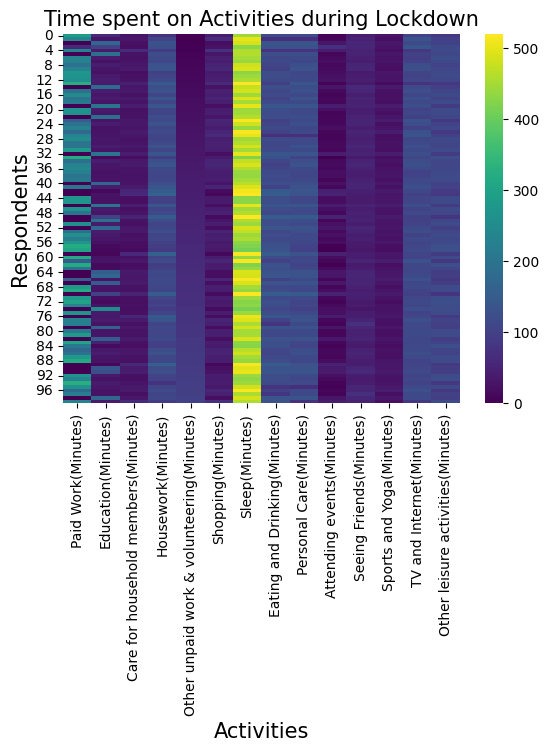

In [ ]:
# Heatmap visualization
plt.figure(dpi=100)
sns.heatmap(Td1, cmap='viridis')
plt.title('Time spent on Activities during Lockdown', fontsize=15)
plt.ylabel('Respondents', fontsize=15)
plt.xlabel('Activities', fontsize=15)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

<Figure size 1280x960 with 0 Axes>

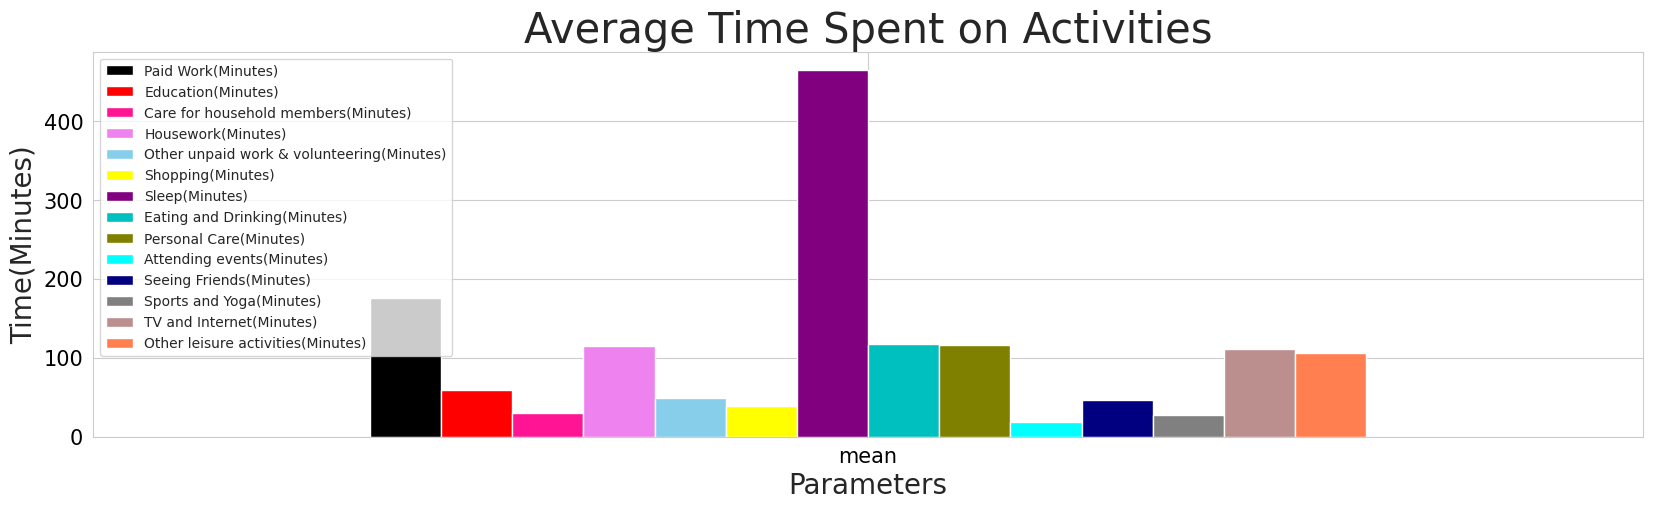

Sleep is observed to be the most liked activity whereas Attending events is the least liked activity during Lockdown.


In [ ]:
# Q1 Bar Graph Analysis
Td2 = Td1.aggregate(['mean'])

sns.set_style("whitegrid")
plt.figure(dpi=200)
Td2.plot.bar(width=0.9, align='center', fontsize=12, figsize=(20,5),
             color=['black', 'red', 'deeppink', 'violet', 'skyblue','yellow','Purple','c','olive', 'cyan','navy','grey','rosybrown','coral'])
plt.title('Average Time Spent on Activities', fontsize=30)
plt.xlabel('Parameters', fontsize=20)
plt.ylabel('Time(Minutes)', fontsize=20)
plt.xticks(fontsize=15, color='Black', rotation=0)
plt.yticks(fontsize=15, color='Black')
plt.show()

print("Sleep is observed to be the most liked activity whereas Attending events is the least liked activity during Lockdown.")

/tmp/ipykernel_2298/876229754.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=Td, palette='Paired')


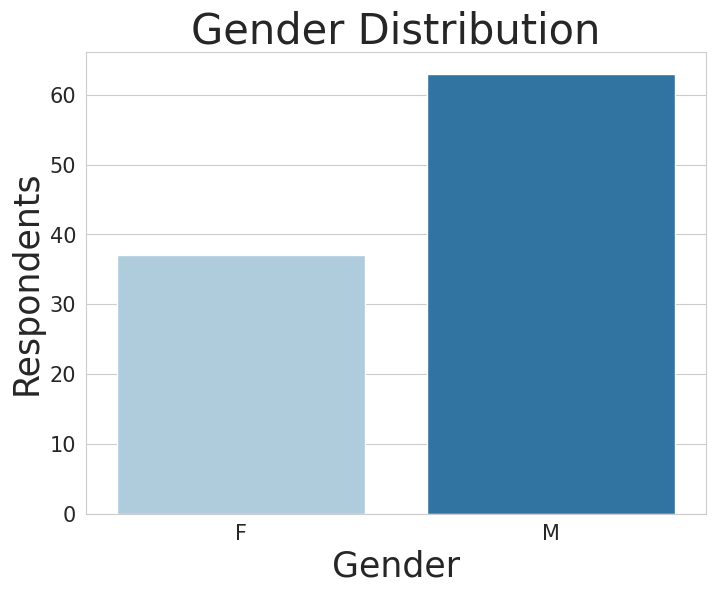

In [ ]:
# Q2 Countplot Analysis
plt.figure(figsize=(8, 6))
sns.countplot(x='Gender', data=Td, palette='Paired')
plt.title('Gender Distribution', fontsize=30)
plt.ylabel('Respondents', fontsize=25)
plt.xlabel('Gender', fontsize=25)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

/tmp/ipykernel_2298/1392896201.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='Housework(Minutes)', x='Gender', data=Td, palette="PuRd")


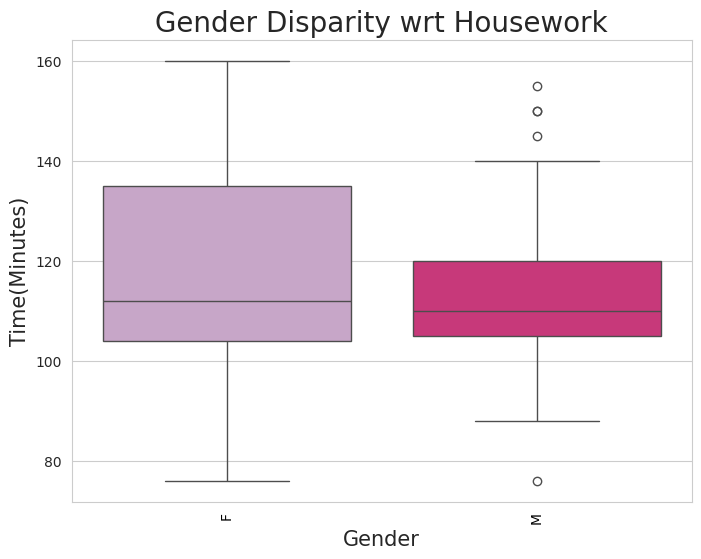

In [ ]:
# Q3 Boxplot Analysis
sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))
sns.boxplot(y='Housework(Minutes)', x='Gender', data=Td, palette="PuRd")
plt.xticks(color='black', rotation=90, horizontalalignment='center')
plt.title('Gender Disparity wrt Housework', fontsize=20)
plt.ylabel('Time(Minutes)', fontsize=15)
plt.xlabel('Gender', fontsize=15)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

/tmp/ipykernel_2298/2062568603.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='Paid Work(Minutes)', x='Gender', data=Td, palette="RdPu")


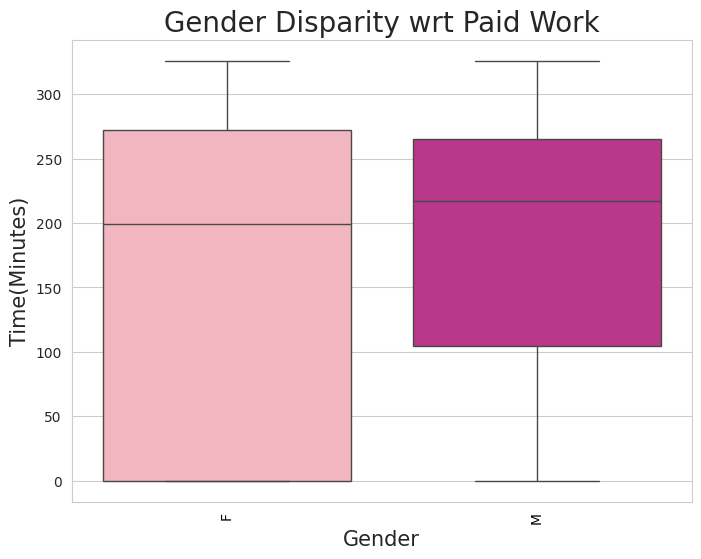

In [ ]:
# Q4 Boxplot Analysis
sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))
sns.boxplot(y='Paid Work(Minutes)', x='Gender', data=Td, palette="RdPu")
plt.xticks(color='black', rotation=90, horizontalalignment='center')
plt.title('Gender Disparity wrt Paid Work', fontsize=20)
plt.ylabel('Time(Minutes)', fontsize=15)
plt.xlabel('Gender', fontsize=15)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

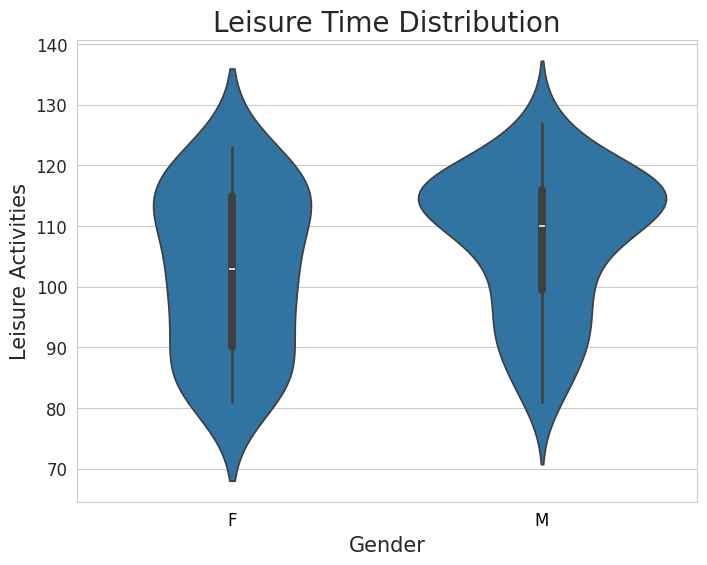

In [ ]:
# Q5 Violin plot Analysis
plt.figure(figsize=(8, 6))
sns.violinplot(y=Td["Other leisure activities(Minutes)"], x=Td["Gender"])
plt.xticks(color='Black')
plt.title('Leisure Time Distribution', fontsize=20)
plt.xlabel('Gender', fontsize=15)
plt.ylabel('Leisure Activities', fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [ ]:
# Q6 Plotly Bar Chart
fig = px.bar(Td, x="Gender", y="Care for household members(Minutes)", color="State")
fig.show()

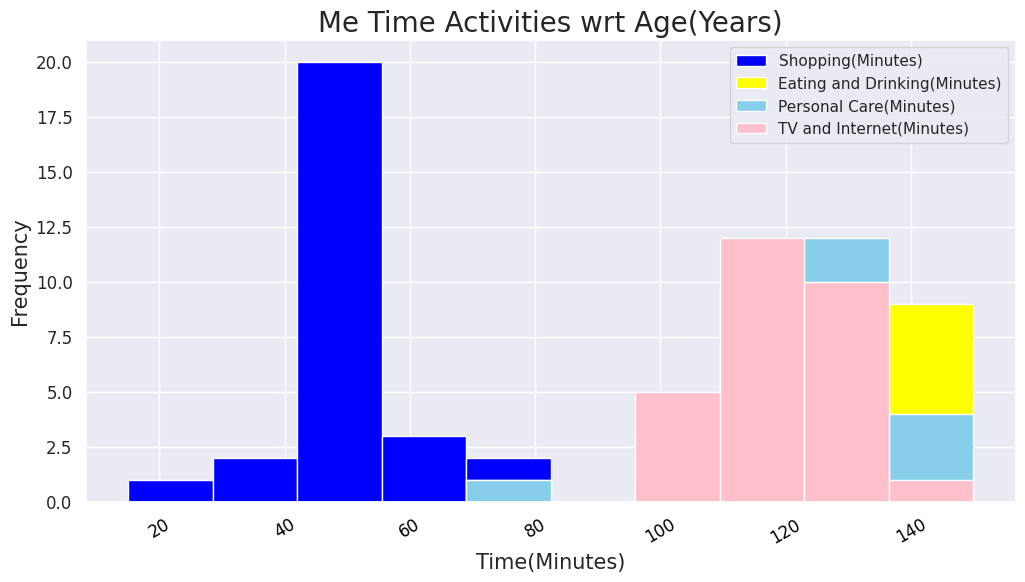

In [ ]:
# Q7 Multi-activity Histogram
sns.set()
Td3 = Td.groupby('State')[['Shopping(Minutes)','Eating and Drinking(Minutes)','Personal Care(Minutes)','TV and Internet(Minutes)']].max()
plt.rc('axes', prop_cycle=(cycler('color', ['blue', 'yellow', 'skyblue','pink'])))

Td3.plot.hist(histtype='barstacked', edgecolor='White', bins=10, figsize=(12,6))
plt.xticks(rotation=30, color='Black')
plt.title('Me Time Activities wrt Age(Years)', fontsize=20)
plt.xlabel('Time(Minutes)', fontsize=15)
plt.ylabel('Frequency', fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

/tmp/ipykernel_2298/3075913658.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




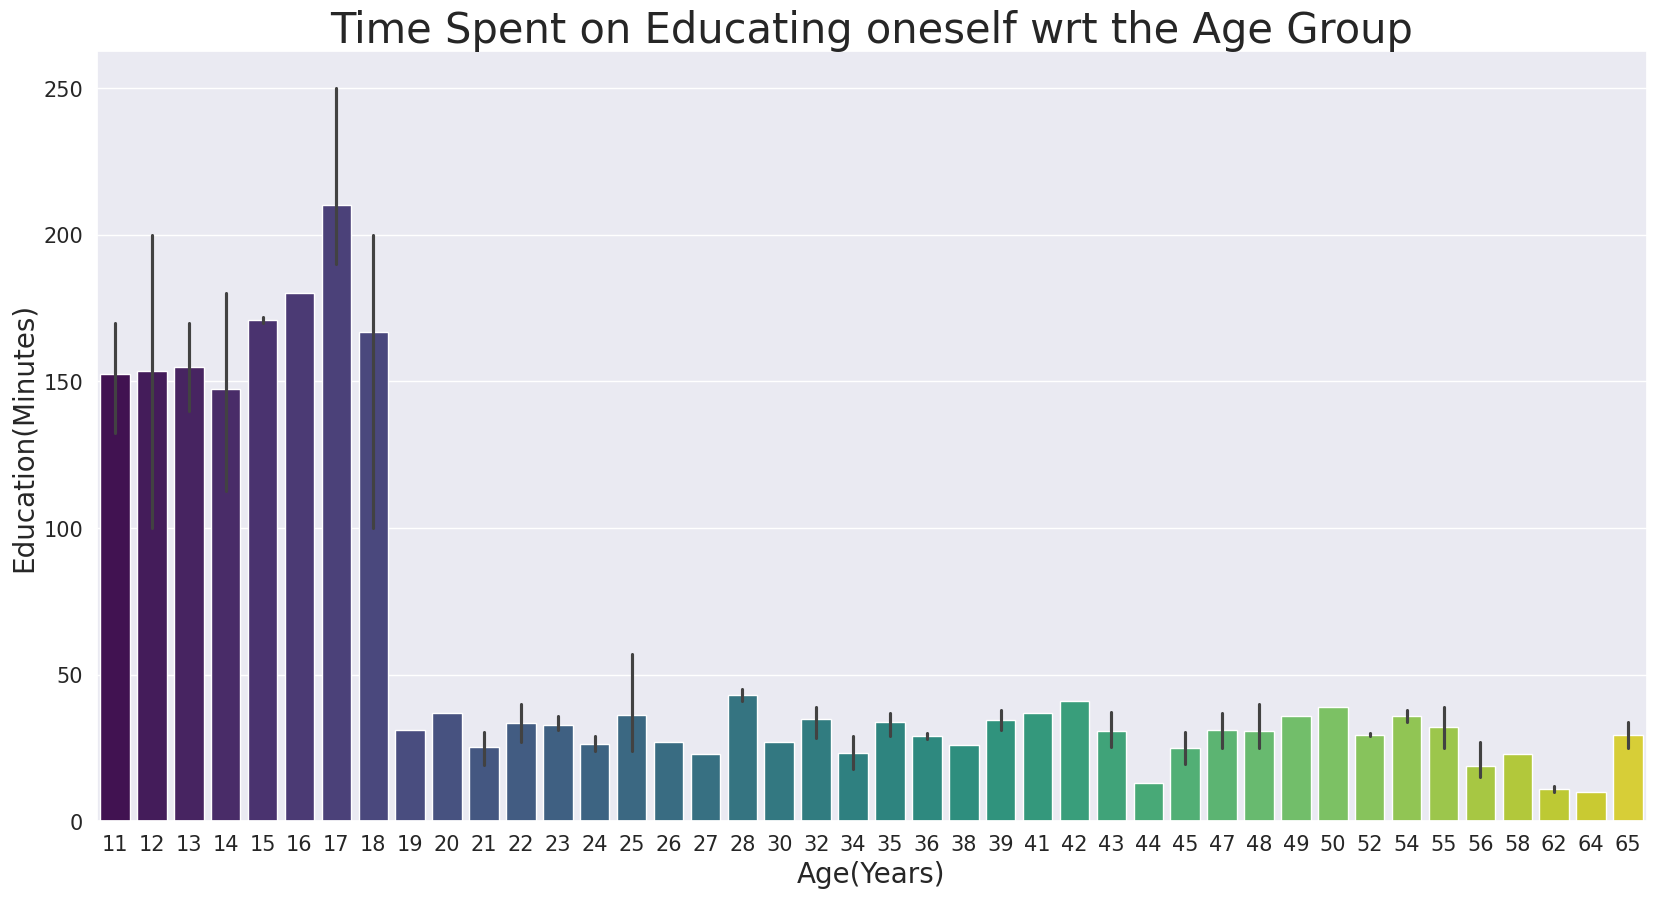

In [ ]:
# Q8 Barplot Analysis
plt.figure(figsize=(20,10))
sns.barplot(x="Age(Years)", y="Education(Minutes)", data=Td, palette="viridis")
plt.title('Time Spent on Educating oneself wrt the Age Group', fontsize=30)
plt.xlabel('Age(Years)', fontsize=20)
plt.ylabel('Education(Minutes)', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

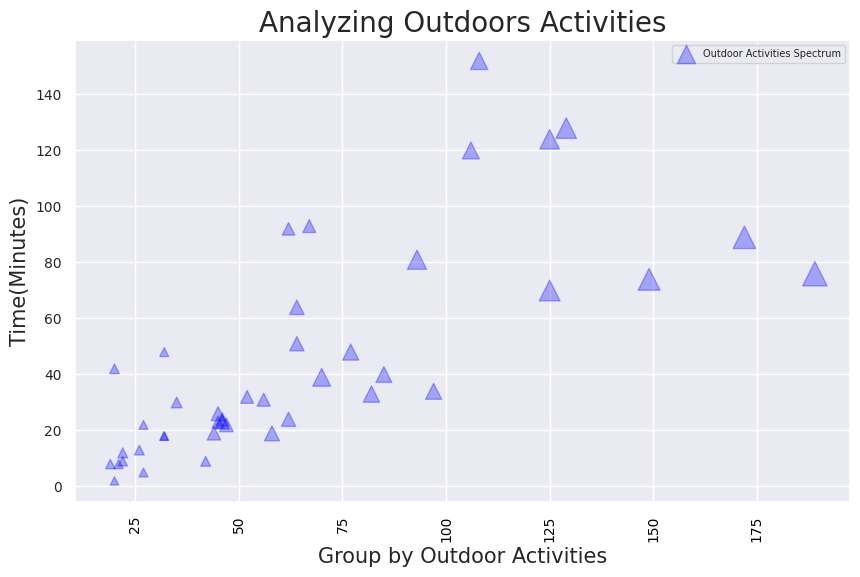

In [ ]:
# Q9 Scatter Metrics
sns.set()
plt.figure(dpi=100, figsize=(10, 6))
sales_data = Td.groupby('Age(Years)')[['Sports and Yoga(Minutes)','Attending events(Minutes)','Seeing Friends(Minutes)']].sum()

plt.scatter(sales_data['Sports and Yoga(Minutes)'], sales_data['Attending events(Minutes)'],
            s=sales_data['Seeing Friends(Minutes)'], color='blue', marker='^', alpha=0.3,
            label='Outdoor Activities Spectrum')
plt.xticks(color='black', rotation=90, horizontalalignment='center')
plt.title('Analyzing Outdoors Activities', fontsize=20)
plt.ylabel('Time(Minutes)', fontsize=15)
plt.xlabel('Group by Outdoor Activities', fontsize=15)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=7)
plt.show()

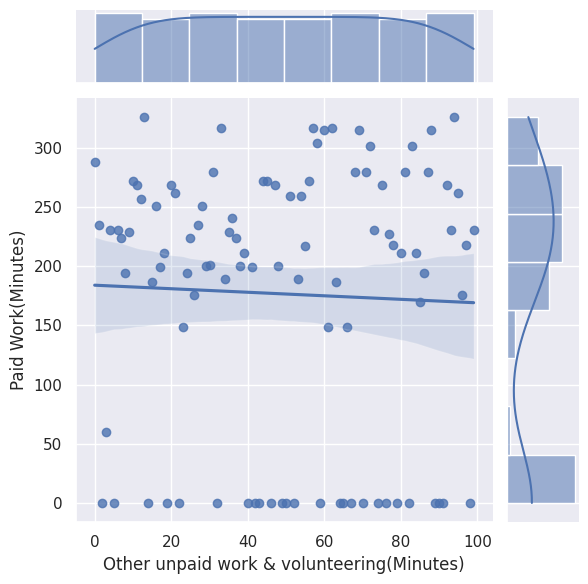

In [ ]:
# Q10 Joint Regression Plot
sns.jointplot(x="Other unpaid work & volunteering(Minutes)", y="Paid Work(Minutes)", data=Td, kind="reg")
plt.show()

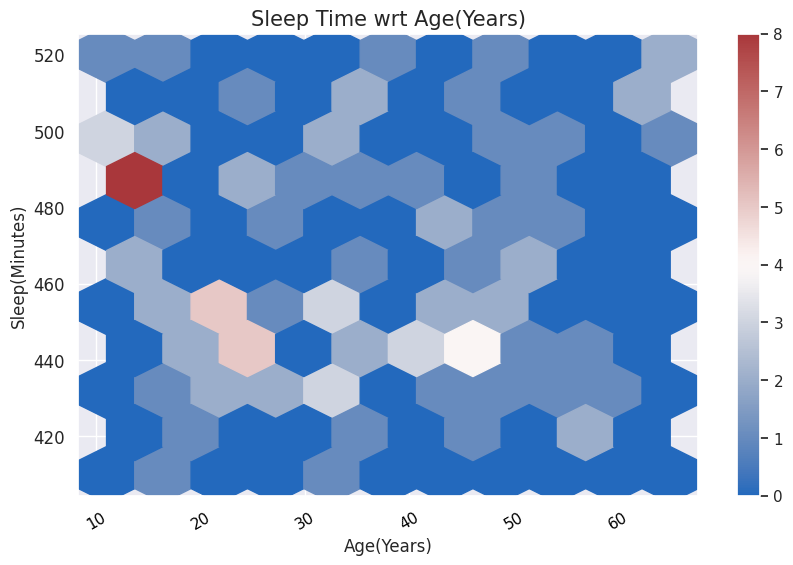

In [ ]:
# Q11 Hexbin Distribution map
Td.plot.hexbin(x='Age(Years)', y='Sleep(Minutes)', gridsize=10, cmap="vlag", figsize=(10,6))
plt.xticks(rotation=30, color='Black')
plt.title('Sleep Time wrt Age(Years)', fontsize=15)
plt.ylabel('Sleep(Minutes)', fontsize=12)
plt.yticks(fontsize=12)
plt.show()

💡 Notice: 'y.png' image file not uploaded to workspace. Generating unmasked variant.


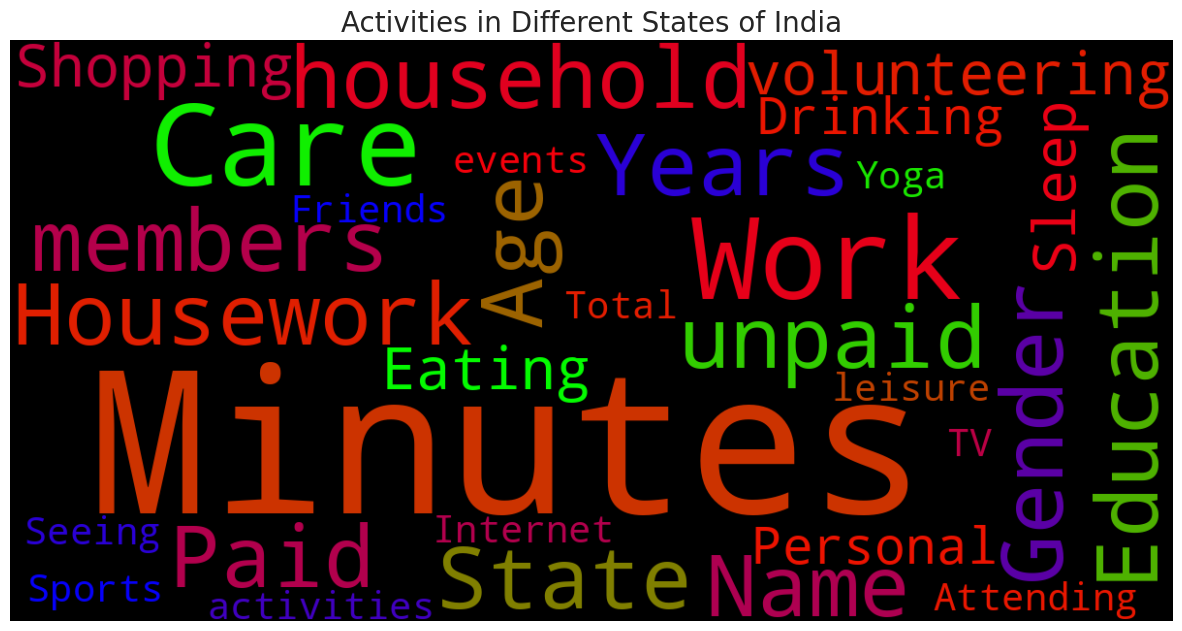

In [ ]:
from wordcloud import WordCloud, ImageColorGenerator
from PIL import Image

# Recreate word string tracking structural metrics
columns_text = " ".join(Td.columns.tolist())

try:
    # Attempt reading image mask if user uploaded it to Colab workspace root
    mask_array = np.array(Image.open('y.png'))
    wc = WordCloud(background_color="black", mask=mask_array, colormap="brg").generate(columns_text)
except FileNotFoundError:
    print("💡 Notice: 'y.png' image file not uploaded to workspace. Generating unmasked variant.")
    wc = WordCloud(background_color="black", width=1200, height=600, colormap="brg").generate(columns_text)

plt.figure(figsize=(15, 10))
plt.imshow(wc, interpolation="bilinear")
plt.title('Activities in Different States of India', size=20)
plt.axis("off")
plt.show()